# DDPM Example Usage

This script walks through the full workflow:
setup → train → save/load → generate → plot.
Make sure the `ddpm/` package folder is in the same directory (or on your PYTHONPATH).

cd "C:\Users\lodik\Documents\programming\diffusion-models-project-main"

git add -A
git commit -m "Overwrite repo with local files"
git push

In [1]:
# --- Setup repo in Colab ---
%cd /content

import os
import sys

repo_path = "/content/ddpm-project-lodi"

if not os.path.exists(repo_path):
    !git clone https://github.com/LodiHendrikKamman/ddpm-project-lodi.git

%cd /content/ddpm-project-lodi
!git pull
!pip install -r requirements.txt

# Make sure Python can find the repo/package
if repo_path not in sys.path:
    sys.path.append(repo_path)

/content
/content/ddpm-project-lodi
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 6 (delta 5), reused 6 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 51.89 KiB | 3.99 MiB/s, done.
From https://github.com/LodiHendrikKamman/ddpm-project-lodi
   81c961b..379a03c  main       -> origin/main
Updating 81c961b..379a03c
Fast-forward
 ddpm/generate.py            |    9 +-
 ddpm/model.py               |    5 +
 lk_example_usage_ddpm.ipynb | 2272 ++++++++++++++++++++++++++++++++++++++++---
 3 files changed, 2174 insertions(+), 112 deletions(-)


In [2]:
# --- Imports ---
import torch

from ddpm import NoiseScheduler, UNet, train, find_lr, generate_image, noisy_image
from ddpm.dataset import load_mnist, get_noisy_loaders
from ddpm.utils import load_unet, channel_list, model_name, path_name
from ddpm.viz import plot_generated
import random
import numpy as np

# --- Expected behaviouring ---
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("Imports worked!")

Using device: cuda
Imports worked!


## 1. Noise scheduler and data

The scheduler defines the beta schedule and handles the forward noising process.
T=1000 steps, linearly spaced betas from 1e-4 to 0.02 (Ho et al. defaults).

In [3]:
scheduler = NoiseScheduler(T=1000, beta_start=1e-4, beta_end=0.02).to(device)

train_set, test_set = load_mnist()
train_loader, test_loader = get_noisy_loaders(train_set, test_set, scheduler, batch_size=32)

In [4]:
# %% [markdown]
# ## Zeros-only ablation: time vs no-time, attention vs no-attention
#
# This replaces the previous two zeros-only training cells.
# We run:
# A: no attention, no time
# B: no attention, with time
# C: attention, no time
# D: attention, with time

# %%
import os
import inspect
import pandas as pd
import matplotlib.pyplot as plt

from ddpm.dataset import get_noisy_loaders_filtered, zeros_only

# --------------------
# Ablation config
# --------------------
ZERO_BATCH_SIZE = 32
ZERO_EPOCHS = 50

# Use same LR for all 4 runs to make the comparison fair.
# If you want to exactly reproduce your old baseline, you can set A's lr to 1e-3 later.
ZERO_LR = 2e-4
ZERO_WEIGHT_DECAY = 1e-6

ZERO_CHANNEL0 = 64
ZERO_CONVS_PER_LEVEL = 2
ZERO_TIME_EMB_DIM = 128
ZERO_TIME_EMB_BASE_DIM = 32

ZERO_SAVE_DIR = "zero_ablation_checkpoints"
os.makedirs(ZERO_SAVE_DIR, exist_ok=True)

# Set True to retrain everything from scratch.
# Set False to reuse checkpoints if they already exist.
ZERO_FORCE_RETRAIN = True

SEED_MODEL = 42
SEED_TRAIN = 123
SEED_SAMPLE = 999


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


print("train signature:", inspect.signature(train))
print("UNet.forward signature:", inspect.signature(UNet.forward))

assert "use_time" in inspect.signature(train).parameters, (
    "Your current Colab repo train() does not have use_time. "
    "Run git pull / restart runtime / re-import ddpm before running this ablation."
)

train signature: (model, train_loader, test_loader, epochs=100, lr=0.01, weight_decay=0.0001, early_stopping_patience=10, save_path='model.pkl', writer=None, use_time=True)
UNet.forward signature: (self, x, t=None)


In [5]:
# %%
set_seed(SEED_TRAIN)

train_loader_zeros, test_loader_zeros = get_noisy_loaders_filtered(
    train_set,
    test_set,
    scheduler,
    filter_fn=zeros_only,
    batch_size=ZERO_BATCH_SIZE,
)

batch = next(iter(train_loader_zeros))
print("Length of one zeros batch:", len(batch))
print("Batch shapes:", [b.shape for b in batch])

assert len(batch) == 3, (
    "For the time-conditioned runs, the dataset must return (x_noisy, noise, t). "
    "Your current dataloader returned only two items, so the time runs cannot work yet."
)

Length of one zeros batch: 3
Batch shapes: [torch.Size([32, 1, 28, 28]), torch.Size([32, 1, 28, 28]), torch.Size([32])]


In [6]:
# %%
def call_unet(model, x, t=None):
    """
    Calls either a time-aware UNet.forward(x, t) or an older UNet.forward(x).
    For the time runs, the model must accept t.
    """
    try:
        return model(x, t)
    except TypeError:
        if t is not None:
            raise TypeError(
                "This model does not accept t, but use_time=True was requested."
            )
        return model(x)


def noisy_image_local(n=1, img_shape=(28, 28), device=device):
    return torch.randn((n, 1, *img_shape), device=device)


def generate_image_zero_ablation(
    unet,
    scheduler,
    stochasticity=1.0,
    n_images=8,
    use_time=True,
    img_shape=(28, 28),
):
    """
    Local DDPM sampler for this ablation.
    Important: use_time=False calls model(x, None), not model(x, t).
    """
    unet.eval()
    model_device = next(unet.parameters()).device

    x = noisy_image_local(n_images, img_shape=img_shape, device=model_device)

    with torch.no_grad():
        for t in range(scheduler.T - 1, 0, -1):
            z = (
                noisy_image_local(n_images, img_shape=img_shape, device=model_device)
                if t > 1
                else torch.zeros_like(x)
            )

            alpha = scheduler.alpha(t).to(model_device)
            alpha_bar = scheduler.alpha_bar(t).to(model_device)
            sigma_t = stochasticity * torch.sqrt(scheduler.beta(t).to(model_device))

            if use_time:
                t_batch = torch.full(
                    (n_images,),
                    t,
                    device=model_device,
                    dtype=torch.long,
                )
                noise_pred = call_unet(unet, x, t_batch)
            else:
                noise_pred = call_unet(unet, x, None)

            x = (1 / torch.sqrt(alpha)) * (
                x - (1 - alpha) / torch.sqrt(1 - alpha_bar) * noise_pred
            ) + sigma_t * z

    return x

In [7]:
# %%
def zero_init_time_projections(model):
    """
    Makes the time path start as a no-op.
    This is useful because the time-conditioning layers should not randomly disturb
    the old no-time architecture at initialization.
    """
    count = 0

    for attr_name in ["encoder_time_projs", "decoder_time_projs"]:
        if hasattr(model, attr_name):
            proj_blocks = getattr(model, attr_name)

            for block in proj_blocks:
                for proj in block:
                    if isinstance(proj, torch.nn.Linear):
                        torch.nn.init.zeros_(proj.weight)
                        torch.nn.init.zeros_(proj.bias)
                        count += 1

    return count


def build_zero_unet(num_heads_att, zero_init_time=True):
    set_seed(SEED_MODEL)

    model = UNet(
        channels=channel_list(ZERO_CHANNEL0),
        convs_per_level=ZERO_CONVS_PER_LEVEL,
        num_heads_att=num_heads_att,
        time_emb_dim=ZERO_TIME_EMB_DIM,
        time_emb_base_dim=ZERO_TIME_EMB_BASE_DIM,
    ).to(device)

    if zero_init_time:
        n_zeroed = zero_init_time_projections(model)
        print(f"Zero-initialized {n_zeroed} time projection layers.")

    n_params = sum(p.numel() for p in model.parameters())
    print(f"Parameters: {n_params:,}")

    return model

In [8]:
# %%
zero_experiments = [
    {
        "name": "A_zero_no_attention_no_time",
        "num_heads_att": 0,
        "use_time": False,
        "lr": ZERO_LR,
        "description": "Old-style baseline: no attention, no time",
    },
    {
        "name": "B_zero_no_attention_with_time",
        "num_heads_att": 0,
        "use_time": True,
        "lr": ZERO_LR,
        "description": "Same as A, but with time conditioning",
    },
    {
        "name": "C_zero_attention_no_time",
        "num_heads_att": 4,
        "use_time": False,
        "lr": ZERO_LR,
        "description": "Attention only, no time",
    },
    {
        "name": "D_zero_attention_with_time",
        "num_heads_att": 4,
        "use_time": True,
        "lr": ZERO_LR,
        "description": "Attention + time conditioning",
    },
]

for exp in zero_experiments:
    print(exp["name"], "|", exp["description"])

A_zero_no_attention_no_time | Old-style baseline: no attention, no time
B_zero_no_attention_with_time | Same as A, but with time conditioning
C_zero_attention_no_time | Attention only, no time
D_zero_attention_with_time | Attention + time conditioning


In [9]:
# %%
zero_models = {}
zero_histories = {}
zero_summary_rows = []

for exp in zero_experiments:
    name = exp["name"]
    save_path = os.path.join(ZERO_SAVE_DIR, f"{name}.pkl")

    print("\n" + "=" * 90)
    print(f"Running {name}")
    print(exp["description"])
    print(f"use_time={exp['use_time']} | num_heads_att={exp['num_heads_att']} | lr={exp['lr']}")
    print("=" * 90)

    model = build_zero_unet(
        num_heads_att=exp["num_heads_att"],
        zero_init_time=True,
    )

    if os.path.exists(save_path) and not ZERO_FORCE_RETRAIN:
        print(f"Loading existing checkpoint: {save_path}")
        model.load_state_dict(torch.load(save_path, map_location=device))
        model.to(device)
        model.eval()
        train_losses = None
        test_losses = None

    else:
        set_seed(SEED_TRAIN)

        train_losses, test_losses = train(
            model,
            train_loader_zeros,
            test_loader_zeros,
            epochs=ZERO_EPOCHS,
            lr=exp["lr"],
            weight_decay=ZERO_WEIGHT_DECAY,
            early_stopping_patience=10,
            save_path=save_path,
            use_time=exp["use_time"],
        )

    zero_models[name] = model
    zero_histories[name] = {
        "train_losses": train_losses,
        "test_losses": test_losses,
        "save_path": save_path,
        "use_time": exp["use_time"],
        "num_heads_att": exp["num_heads_att"],
        "lr": exp["lr"],
    }

    if train_losses is not None:
        zero_summary_rows.append({
            "name": name,
            "use_time": exp["use_time"],
            "num_heads_att": exp["num_heads_att"],
            "lr": exp["lr"],
            "final_train_loss": train_losses[-1],
            "best_train_loss": min(train_losses),
            "final_test_loss": test_losses[-1],
            "best_test_loss": min(test_losses),
            "checkpoint": save_path,
        })
    else:
        zero_summary_rows.append({
            "name": name,
            "use_time": exp["use_time"],
            "num_heads_att": exp["num_heads_att"],
            "lr": exp["lr"],
            "final_train_loss": None,
            "best_train_loss": None,
            "final_test_loss": None,
            "best_test_loss": None,
            "checkpoint": save_path,
        })

zero_summary_df = pd.DataFrame(zero_summary_rows)
display(zero_summary_df)


Running A_zero_no_attention_no_time
Old-style baseline: no attention, no time
use_time=False | num_heads_att=0 | lr=0.0002
Zero-initialized 10 time projection layers.
Parameters: 2,051,329


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

train:   0%|          | 0/186 [00:00<?, ?it/s]

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 0 | train loss: 0.2766 | test loss: 0.1280


...

Epoch 29 | train loss: 0.0280 | test loss: 0.0290


train:   0%|          | 0/186 [00:00<?, ?it/s]

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 30 | train loss: 0.0283 | test loss: 0.0261
Early stopping at epoch 30


,name,use_time,num_heads_att,lr,final_train_loss,best_train_loss,final_test_loss,best_test_loss,checkpoint
0,A_zero_no_attention_no_time,False,0,0.0002,0.031103,0.030620,0.030537,0.026906,zero_ablation_checkpoints/A_zero_no_attention_...
1,B_zero_no_attention_with_time,True,0,0.0002,0.028633,0.028364,0.026383,0.026201,zero_ablation_checkpoints/B_zero_no_attention_...
2,C_zero_attention_no_time,False,4,0.0002,0.031421,0.031109,0.029370,0.029044,zero_ablation_checkpoints/C_zero_attention_no_...
3,D_zero_attention_with_time,True,4,0.0002,0.028254,0.028013,0.026140,0.026002,zero_ablation_checkpoints/D_zero_attention_wit...


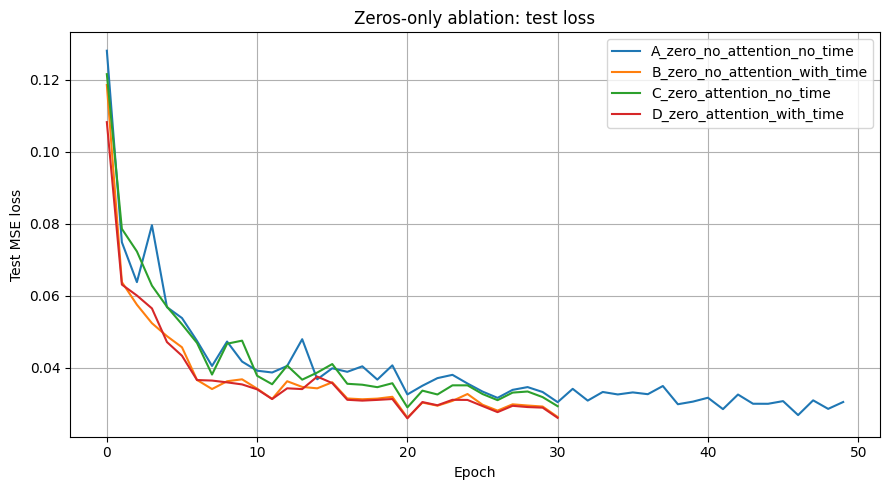

In [10]:
# %%
plt.figure(figsize=(9, 5))

for name, hist in zero_histories.items():
    test_losses = hist["test_losses"]

    if test_losses is not None:
        plt.plot(test_losses, label=name)

plt.xlabel("Epoch")
plt.ylabel("Test MSE loss")
plt.title("Zeros-only ablation: test loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Generating samples for A_zero_no_attention_no_time
use_time during generation = False
A_zero_no_attention_no_time


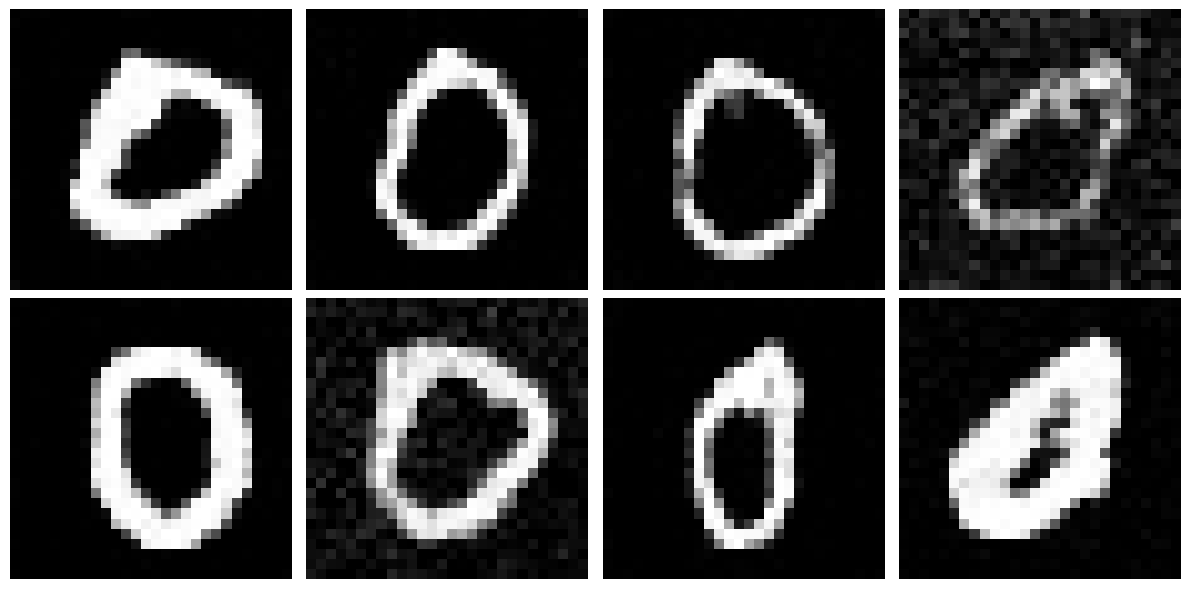


Generating samples for B_zero_no_attention_with_time
use_time during generation = True
B_zero_no_attention_with_time


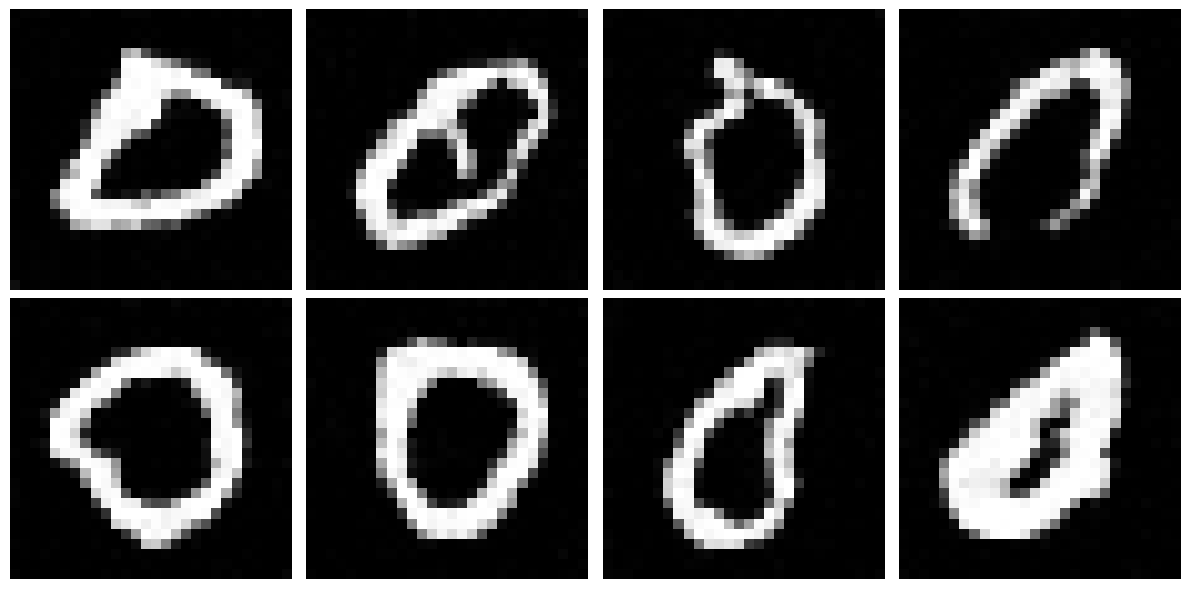


Generating samples for C_zero_attention_no_time
use_time during generation = False
C_zero_attention_no_time


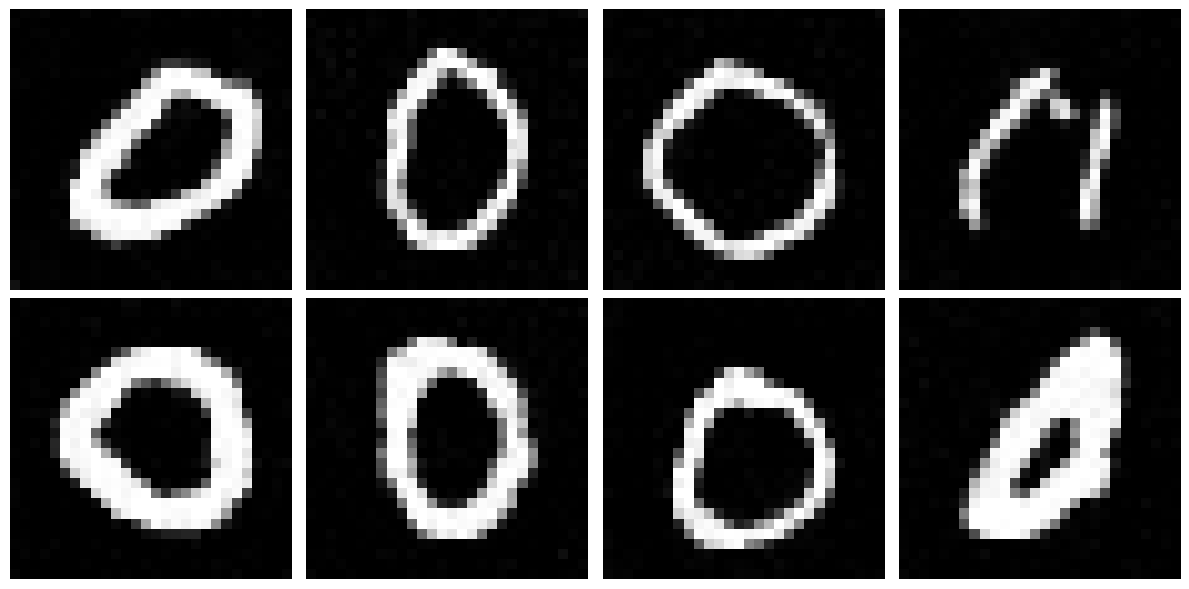


Generating samples for D_zero_attention_with_time
use_time during generation = True
D_zero_attention_with_time


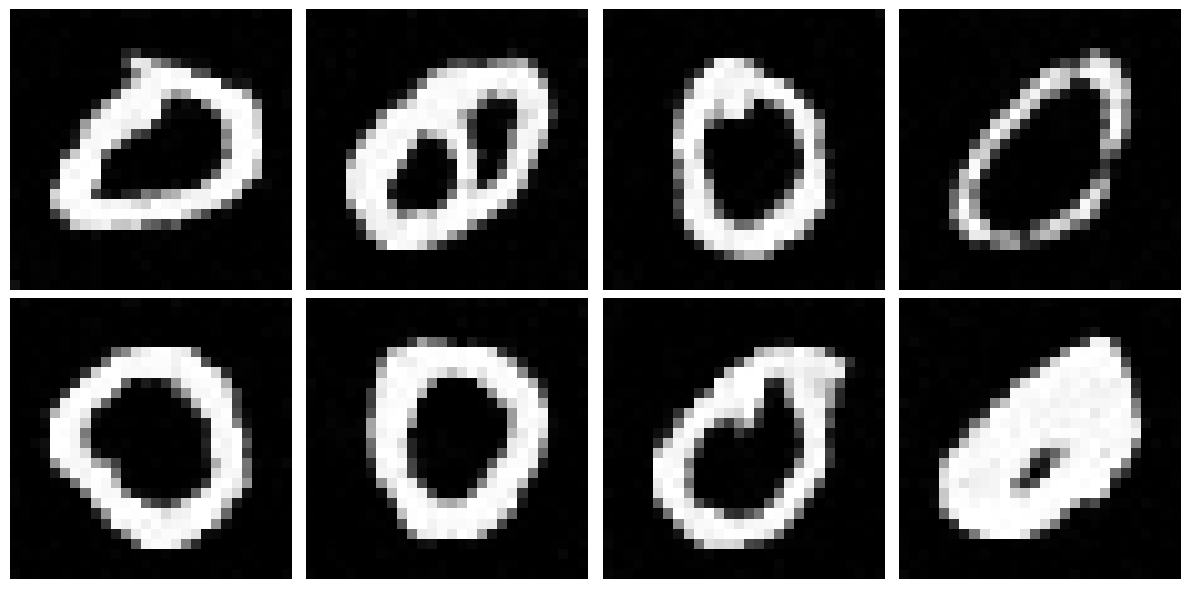

In [11]:
# %%
zero_samples = {}

for exp in zero_experiments:
    name = exp["name"]

    print("\n" + "=" * 90)
    print(f"Generating samples for {name}")
    print(f"use_time during generation = {exp['use_time']}")
    print("=" * 90)

    set_seed(SEED_SAMPLE)

    x = generate_image_zero_ablation(
        zero_models[name],
        scheduler,
        n_images=8,
        stochasticity=1.0,
        use_time=exp["use_time"],
    )

    zero_samples[name] = x.detach().cpu()

    print(name)
    plot_generated(x, ncol=4)

In [12]:
# %%
def time_effect_diagnostic(model, loader):
    model.eval()

    batch = next(iter(loader))
    x_noisy = batch[0].to(device)
    t = batch[2].to(device)

    with torch.no_grad():
        y_none = call_unet(model, x_noisy, None)
        y_time = call_unet(model, x_noisy, t)

    return (y_none - y_time).abs().mean().item()


diag_rows = []

for exp in zero_experiments:
    name = exp["name"]

    diff = time_effect_diagnostic(zero_models[name], test_loader_zeros)

    diag_rows.append({
        "name": name,
        "trained_with_time": exp["use_time"],
        "num_heads_att": exp["num_heads_att"],
        "mean_abs_diff_model_x_none_vs_x_t": diff,
    })

diag_df = pd.DataFrame(diag_rows)
display(diag_df)

,name,trained_with_time,num_heads_att,mean_abs_diff_model_x_none_vs_x_t
0,A_zero_no_attention_no_time,False,0,0.000000
1,B_zero_no_attention_with_time,True,0,0.732639
2,C_zero_attention_no_time,False,4,0.000000
3,D_zero_attention_with_time,True,4,0.423701
